# **CESM amip water tracer -  ENSO pattern reseach**
This notebook focuses on the comparison in different dimensions of years considered as El Nino years vs La Nina years
It also includes the dertermination of the El Nino Index 
This notebook requires a prior storage of integrated water vapour (cell 22 of Sanity checks notebook)

## **Initial Set Up-related**

### Imports

In [5]:
%matplotlib inline
########## OS Interaction ##########
import os
import sys
import cftime

########## General ##########
import numpy as np
import netCDF4 as nc
import xarray as xr
import scipy as sp
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.colors as colors 
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import ticker
from matplotlib import gridspec
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar

########## Cartopy+ Shapely ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from mpl_toolkits.axes_grid1 import make_axes_locatable


### Function Definitions

In [6]:
# Overall: unstacks time for an input data set
def unstack_time(ds_in):

    # Groups by year or months , calculates the mean, then takes/assigns the resulting values
    years = ds_in.groupby('time.year').mean('time').year
    months = ds_in.groupby('time.month').mean('time').month

    # Makes a pandas MultiIndex that is years x months
    midx = pd.MultiIndex.from_product([years.values,months.values], names=("year","month"))

    # Creates a temporary data set copy from ds_in, multiindex yxm and assign it 
    ds_temp = ds_in.copy()
    ds_temp = ds_temp.assign_coords({'time':midx})
    ds_out = ds_temp.unstack()
    return ds_out

##########

# Overall: creates a vertical integration function accounting for totpography and surface pressure
def vert_int_hybrid(ds, var, ds_hybrid):
    g    = 9.80665   # m/s²
    P0   = 100000.   # Pa  (standard reference pressure)

    q    = ds[var]
    PS   = ds_hybrid['PS']    # surface pressure  (Pa)
    hyai = ds_hybrid['hyai']  # interface A coefficients
    hybi = ds_hybrid['hybi']  # interface B coefficients

    # Interface pressures at every grid point & level interface
    P_i = hyai * P0 + hybi * PS          # shape: (time, ilev, lat, lon)

    # Pressure thickness of each model layer
    dp = P_i.diff(dim='ilev')            # shape: (time, ilev-1, lat, lon)
    dp = dp.transpose("time", "ilev", "lat", "lon")

    # Copy dp into a DataArray that shares 'lev' dim with q
    dp_lev = ds[var].copy() * 0.0
    dp_lev.values = dp.values

    # Hydrostatic column integral: Σ (q·dp) / g
    layer_int = (q * dp_lev) / g
    total_int = layer_int.sum(dim='lev', skipna=True)
    return total_int
    

### data path and Variable Definitions

In [23]:
# Data Path
data_dir =  '/scratch/st-mlague-1/mlague/data/iCESM/'


# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','PRECC', 'LHFLX','PRECL','Q','TMQ','LNDV','NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] # PS is added for the vertical integration
static_vars = ['hyai', 'hybi','PS'] # variables for the hybrid integration

# tracer list,and dictionary associating it with a name
tracer_realnames = ['Q','LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
tracer_shortnames = ['All Land and Oceans','All Land', 'North Pole', 'North America', 'Europe/Northern Africa', 'Eastern Asia', 'Central South America', 'Central Africa', 'Maritime Continent', 'South America', 'South Africa', 'Australia', 'South Pole']
tracer_dict_reversed = dict(zip(tracer_realnames, tracer_shortnames))

# case list, dictionary associating it with a name
case_list = ['icesm_continents_sst'] #case list
short_list=['amip'] # case list names
short_names = dict(zip(case_list, short_list))


### Dictionary Definitions

In [8]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

for case in case_list:
    # Defines the time series directory name for the case
    ts_dir = Path(data_dir) / case / 'TimeSeries'

    # Build the list of atm files with pathlib,
    file_list_atm = []
    ds_static_list = []
    for var in atm_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))

        if not files:
            print(f'oh no, no variables for {var}')
        else:
            for file in files:
                    file_list_atm.append(file)
        print( 'got the data from', var) 
        
    # static variables for the integral function
    for var in static_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))
        if not files:
            print(f'oh no, no file for {var}')
        else:
            ds_static_list.append(xr.open_dataset(files[0], engine='netcdf4'))  # ONE file, ONE var
        print('got the data from', var)
        
    # Open the variables all at once without dropping any years
    ds_temp_atm = xr.open_mfdataset(file_list_atm, engine='netcdf4', compat='override',chunks={'time': 36, 'lev': 30, 'lat': 48, 'lon': 72} )
    ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,323)) # Drops the first year
    ds_temp_static = xr.merge(ds_static_list)
    ds_static_coeffs = ds_temp_static[['hyai', 'hybi', 'P0']]
    ds_static_PS = ds_temp_static['PS'].isel(time=slice(11, 323))
    
    # Merge everything
    ds_temp_atm_short = xr.merge([ds_temp_atm_short, ds_static_coeffs, ds_static_PS], join='override')

    print('data put together and cut!')
    short = short_names[case]
    ds_temp_atm_short.attrs['title'] = short  # assign the short name as the title
    ts_dict_atm[short] = ds_temp_atm_short.copy()
    del ds_temp_atm, ds_temp_atm_short  # Deletes the temporary data sets

got the data from TS
got the data from TREFHT
got the data from PRECC
got the data from LHFLX
got the data from PRECL
got the data from Q
got the data from TMQ
got the data from LNDV
got the data from NPV
got the data from NAV
got the data from EUV
got the data from EAV
got the data from CSAV
got the data from CAFV
got the data from MARV
got the data from SAV
got the data from SAFV
got the data from AUSV
got the data from SPV
got the data from hyai
got the data from hybi
got the data from PS
data put together and cut!


### Weighting and dimension check

In [9]:
# Weights the latitude, renames it to "weights"
weights = np.cos(np.deg2rad(ts_dict_atm['amip']['TS'].lat))
weights.name = "weights"

## **Data Analysis-related**

### differential maps in La Nina / El Nino years

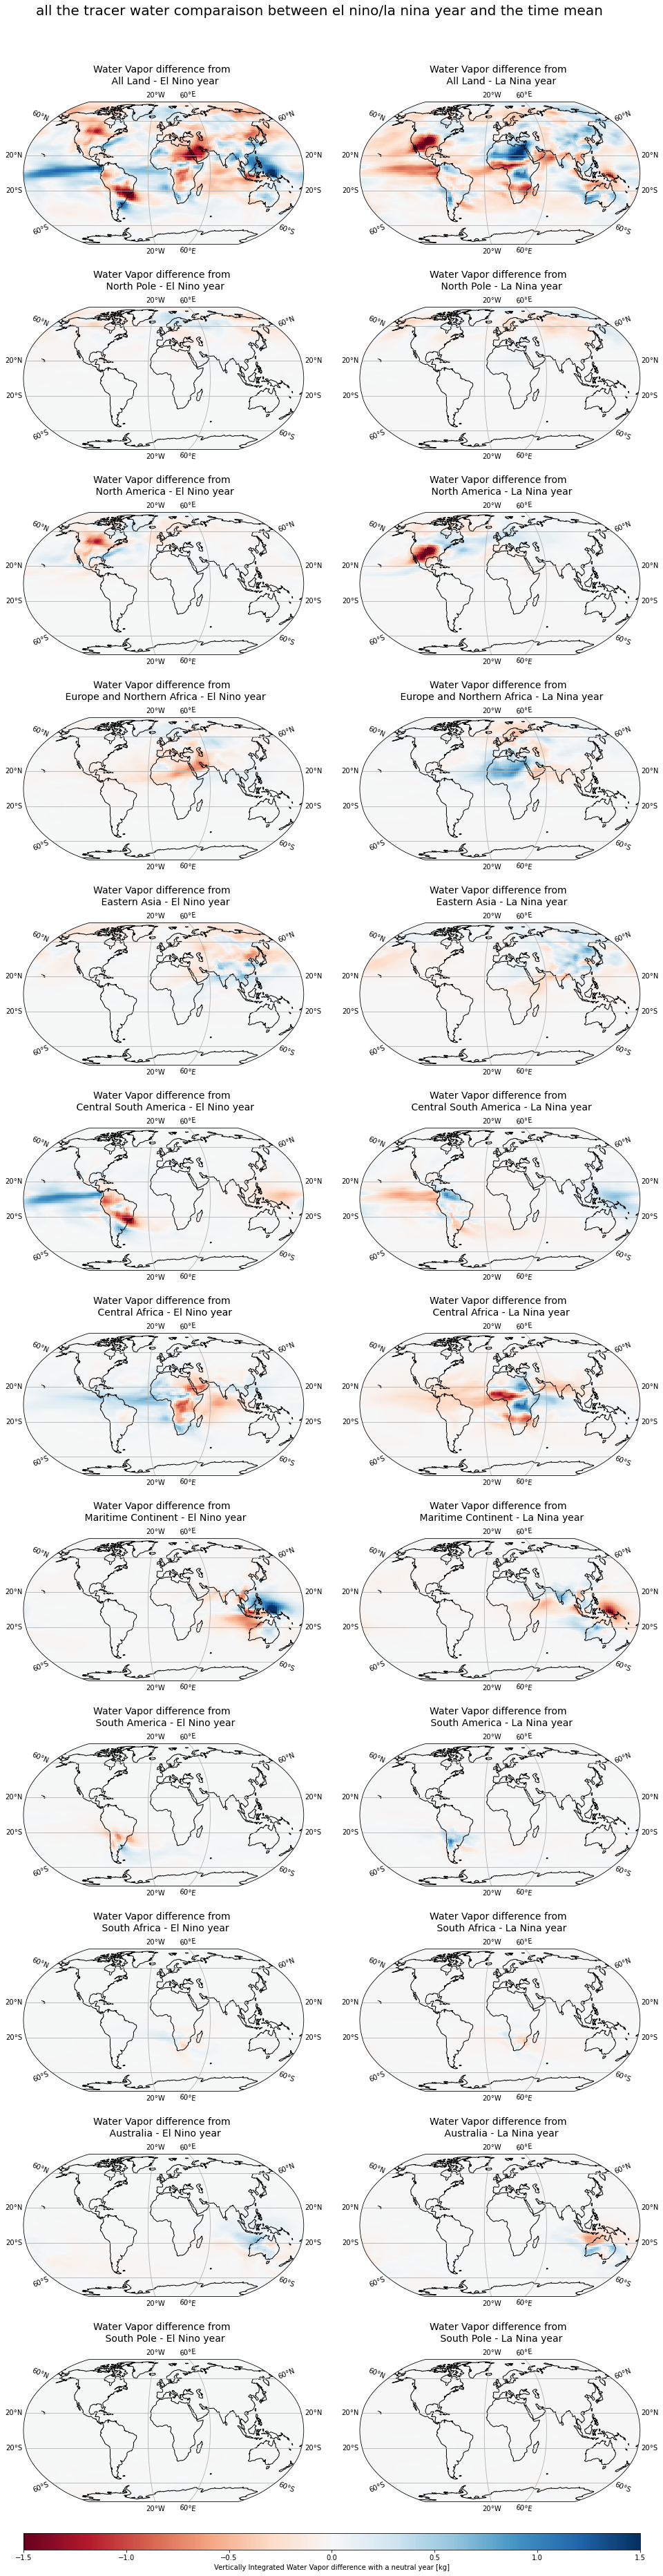

In [9]:
## Robinson map plot for every tracer : vapor el nino year (1982) -  neutral year (2001) and la nina (1999) - time mean
case = 'amip'
tracer_list = ['LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
year_select = [1982, 1999]
neutral_year=2001
clim =[-1.5,1.5]

fig = plt.figure(figsize=(16, 66))                       
gs = fig.add_gridspec(13, 2,height_ratios=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.08],hspace=0.)                
ax_list = [[fig.add_subplot(gs[i, j], projection=ccrs.Robinson()) for j in range(2)] for i in range(12)]
ax_cb = fig.add_subplot(gs[12, :])

names=['El Nino year', 'La Nina year']

for i, tracer in enumerate(tracer_list):
    #for the tracer : veetical integration and time mean 
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")
    data_mean = data_integrated.mean(dim ='time') 
    
    for j, year in enumerate(year_select):
        ax = ax_list[i][j]
    #vertical integration and time mean for the chosen year (el Nino or la nina) 
        data_chosen_year = data_integrated.sel(time=data_integrated.time.dt.year == year).mean('time')
        data_year= data_chosen_year - data_mean # we want to plot the difference
    #add cyclic point and plot the data
        data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) 
        figure = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='RdBu',vmin=clim[0], vmax=clim[1],shading='auto')
    #add coastlines, gridlines, title 
        ax.coastlines()
        ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60]) 
        ax.set_title(f'Water Vapor difference from \n {tracer_dict_reversed[tracer]} - {names[j]}', fontsize=14, pad=10)

cbar = fig.colorbar(figure, cax=ax_cb, orientation='horizontal', label='Vertically Integrated Water Vapor difference with a neutral year [kg]')
fig.suptitle('all the tracer water comparaison between el nino/la nina year and the time mean ', fontsize=20, y=0.9)
plt.show()
plt.close(fig)

### Line plots comparison between EL Niño and La Nina years ###

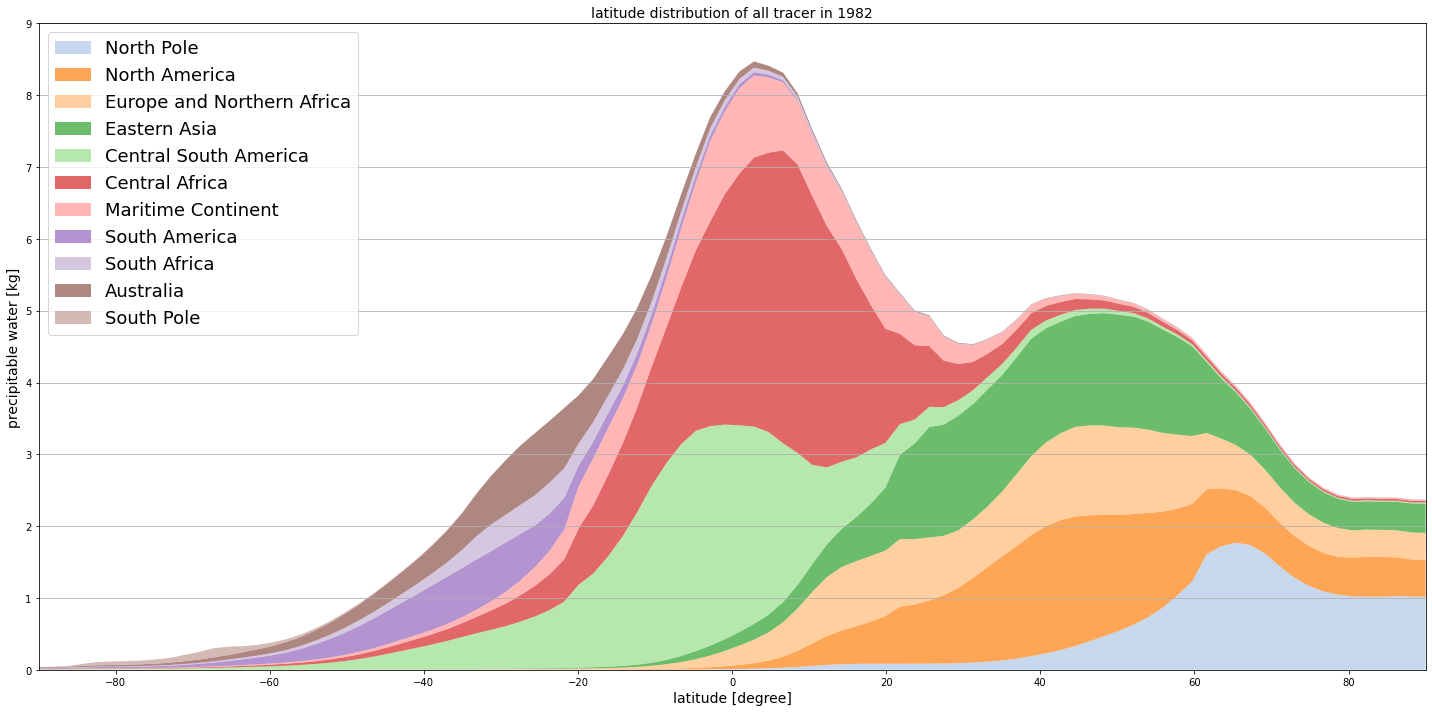

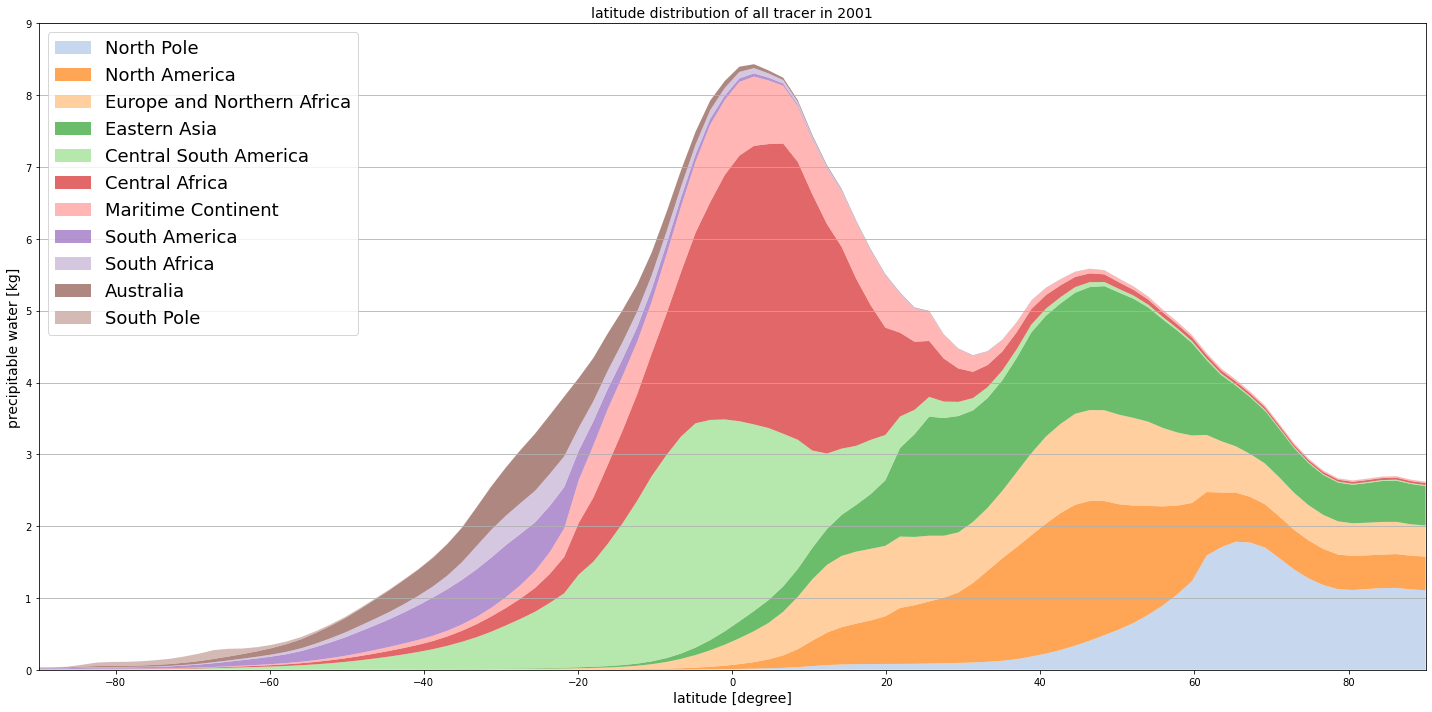

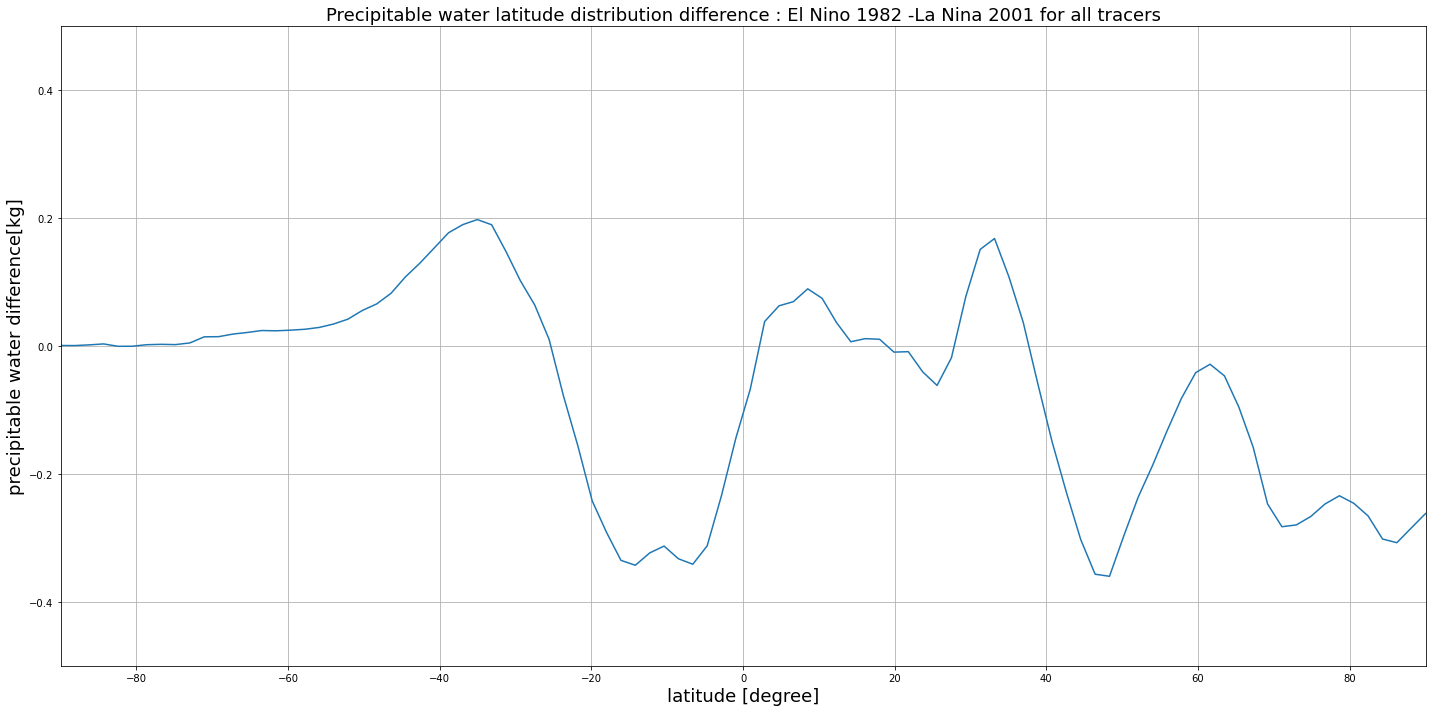

In [14]:
# Side by side stackplots (El Nino vs La Nina) + difference line plot below
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']
years = [1982,2001]

for year in years:
    plt.figure(figsize=(20, 10))
    all_lats = None
    all_values = []
    for tracer in tracer_list:
        data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")# shape: (lat, lon,time)
        tracer_zm = data_integrated.mean(dim='lon')#shape :(lat, time)
        tracer_ts = tracer_zm.sel(time=tracer_zm.time.dt.year == year).mean('time') # shape: (lat)
        all_values.append(tracer_ts.values)#add the new value eah time 
    
    # stack plot    
    all_lats = tracer_ts.lat.values 
    labels = [tracer_dict_reversed[t] for t in tracer_list] # tracers names
    colors = [plt.cm.tab20.colors[i % 20] for i in range(1,len(tracer_list)+1)] # color for each tracer
    plt.stackplot(all_lats, all_values, labels=labels, colors=colors, alpha=0.7)

    # layout : axis, grid, lengend and title
    plt.xlim(all_lats.min(), all_lats.max())  # or plt.xlim(-90, 90)
    plt.ylim(0,9)
    plt.xlabel('Latitude [°N]', fontsize=14)
    plt.ylabel('Column integrated water vapour [kg/m2]', fontsize=14)
    plt.title(f'latitude distribution of all tracer in {year}', fontsize=14)
    plt.grid(axis='y')
    plt.legend(fontsize=18,loc='upper left')
    plt.tight_layout()
    plt.show()

# difference between el nino and la nina years : the total diff between the 2 yars
plt.figure(figsize=(20, 10))
all_values = 0
tracer='LNDV' # comparison for all land
data_integrated =xr.open_dataarray("vert_int_output/"+tracer+".nc")# shape: (lat, lon,time)
tracer_zm = data_integrated.mean(dim='lon')#shape :(lat, time)
tracer_ts_Nino = tracer_zm.sel(time=tracer_zm.time.dt.year == Nino).mean('time') # shape: (lat) => select the nino year
tracer_ts_Nina = tracer_zm.sel(time=tracer_zm.time.dt.year == Nina).mean('time') # shape: (lat)=> select the nina year
all_values =tracer_ts_Nino - tracer_ts_Nina # difference : Nino - Nina
all_lats = all_values.lat.values # select the latitude value on any tracer or year

plt.plot(all_lats, all_values)  # plot

# layout : axis, grid and title
plt.xlim(-90, 90)
plt.ylim(-0.5,0.5)
plt.xlabel('Latitude [°N]', fontsize=18)
plt.ylabel('Column integrated water vapour [kg/m2]', fontsize=18)
plt.title(f'Water vapour  difference in latitude distribution : El Nino {Nino} -La Nina {Nina} for all tracers', fontsize=18)
plt.grid()
plt.tight_layout()
plt.show()

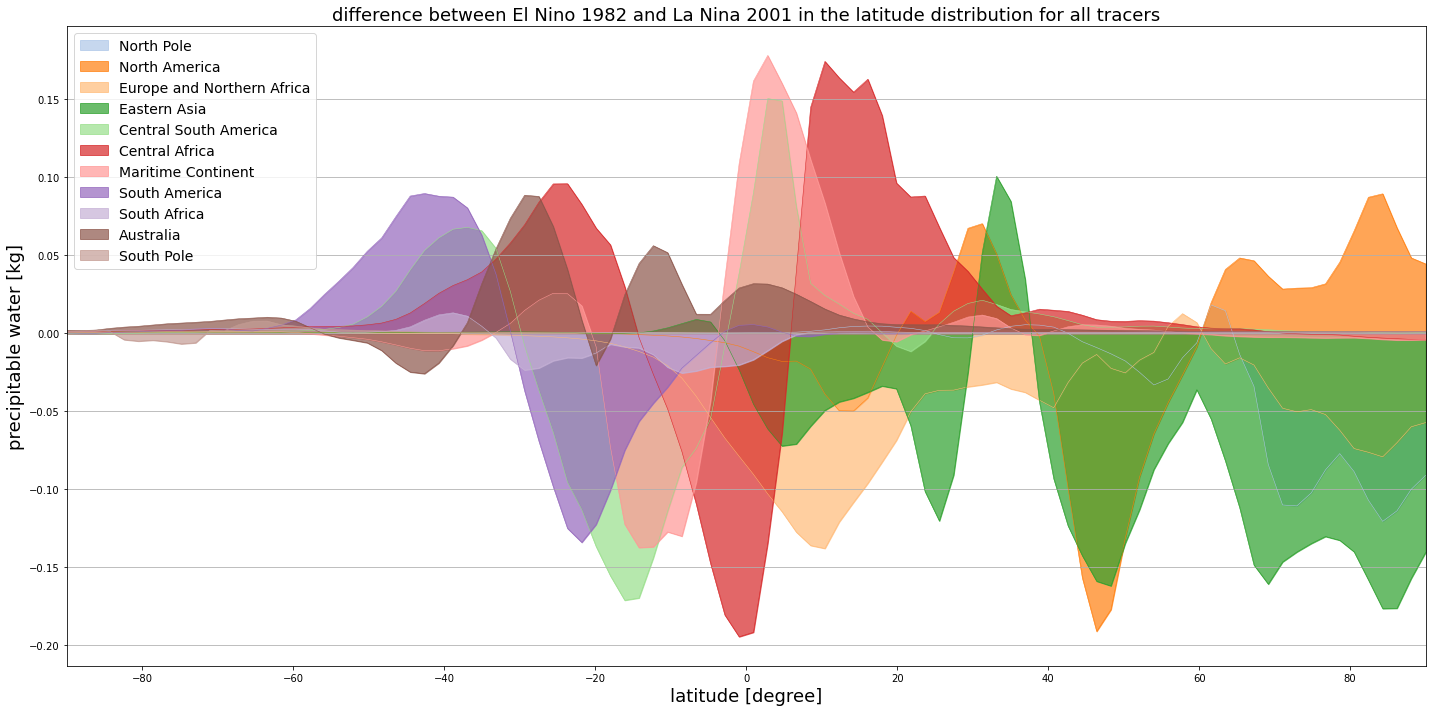

In [12]:
# differencial stackline plot between el nino and la nina years :
#latitude distribution of vertically integrated vapor for all tracers
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']
Nina = 2001
Nino = 1982

plt.figure(figsize=(20, 10))

all_lats = None
all_values = []

for tracer in tracer_list:
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")# shape: (lat, lon,time)
    tracer_zm = data_integrated.mean(dim='lon')#shape :(lat, time)
    tracer_ts_Nino = tracer_zm.sel(time=tracer_zm.time.dt.year == Nino).mean('time') # shape: (lat) => select the nino year
    tracer_ts_Nina = tracer_zm.sel(time=tracer_zm.time.dt.year == Nina).mean('time') # shape: (lat)=> select the nina year
    tracer_ts =tracer_ts_Nino - tracer_ts_Nina # difference : Nino - Nina
    all_values.append(tracer_ts.values) # add the value each time 
labels = [tracer_dict_reversed[t] for t in tracer_list]    
    
all_lats = tracer_ts.lat.values # select the latitude value on any tracer or year

# Stack et area plot
colors = [plt.cm.tab20.colors[i % 20] for i in range(1,len(tracer_list)+1)]
for i, (values, label) in enumerate(zip(all_values, labels)):
    plt.fill_between(all_lats, values, 0, alpha=0.7, label=label, color=colors[i % len(colors)])
    plt.plot(all_lats, values, color=colors[i % len(colors)], linewidth=0.5)   

plt.xlim(-90, 90)
#plt.ylim(0, 9)
plt.xlabel('latitude [degree]', fontsize=18)
plt.ylabel('precipitable water [kg]', fontsize=18)

plt.title(f'difference between El Nino {Nino} and La Nina {Nina} in the latitude distribution for all tracers', fontsize=18)
plt.grid(axis='y')
plt.legend(fontsize=14,loc='upper left')
plt.tight_layout()
plt.show()

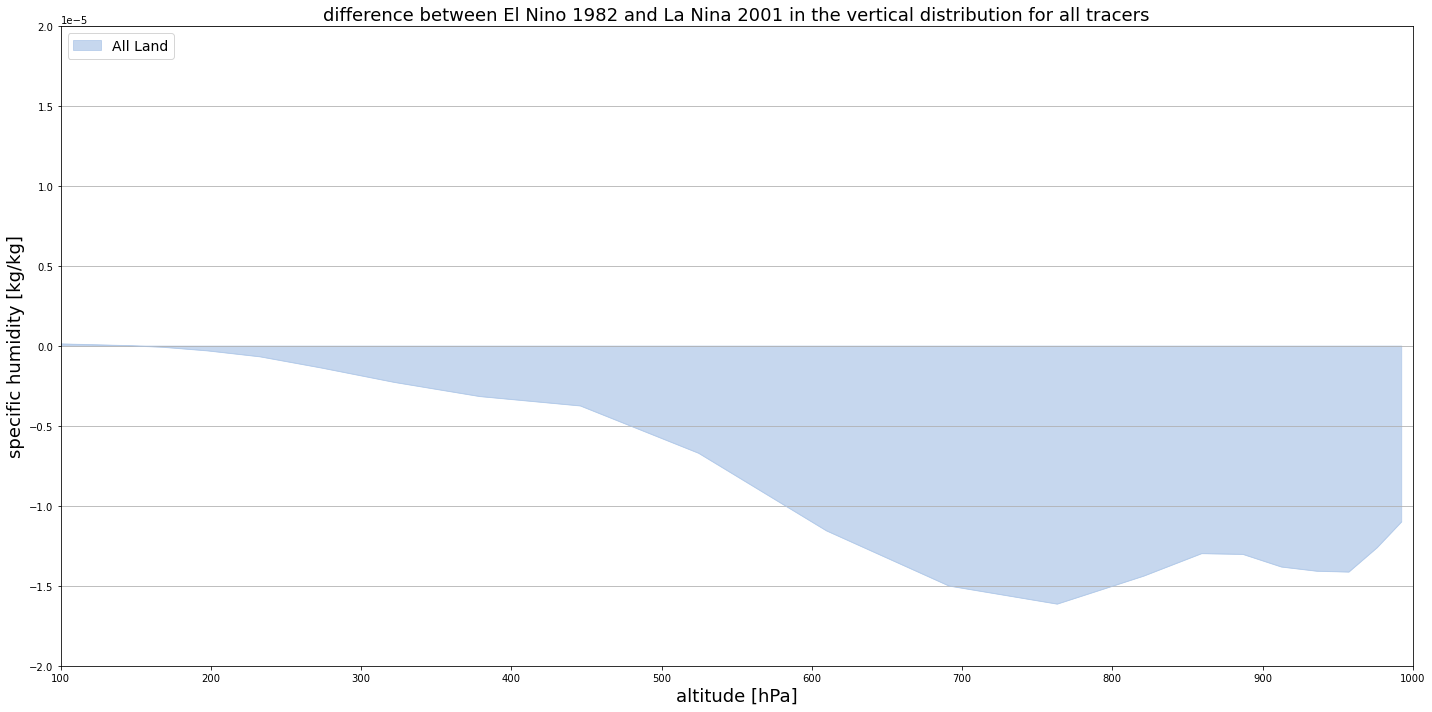

In [17]:
# difference between el nino and la nina years in the altitude distribution
case = 'amip'
tracer_list = ['LNDV']
Nina = 2001
Nino = 1982

plt.figure(figsize=(20, 10))

all_levs = None
all_values = []

for tracer in tracer_list:
    tracer_lm = ts_dict_atm[case][tracer].mean(dim='lat')# shape: (lev lon,time)
    tracer_zm = tracer_lm.mean(dim='lon')#shape :(lat, time)
    tracer_ts_Nino = tracer_zm.sel(time=tracer_zm.time.dt.year == Nino).mean('time') # shape: (lat) => select the nino year
    tracer_ts_Nina = tracer_zm.sel(time=tracer_zm.time.dt.year == Nina).mean('time') # shape: (lat)=> select the nina year
    tracer_ts =tracer_ts_Nino - tracer_ts_Nina # difference : Nino - Nina
    all_values.append(tracer_ts.values) # add the value each time 
labels = [tracer_dict_reversed[t] for t in tracer_list]    
    
all_levs = tracer_ts.lev.values # select the latitude value on any tracer or year

# Stack et area plot
colors =[plt.cm.tab20.colors[i % 20] for i in range(1,len(tracer_list)+1)]
for i, (values, label) in enumerate(zip(all_values, labels)):
    plt.fill_between(all_levs, values, 0, alpha=0.7, label=label, color=colors[i % len(colors)])
    plt.plot(all_levs, values, color=colors[i % len(colors)], linewidth=0.5)   

plt.xlim(100,1000)
plt.ylim(-2e-5, 2e-5)
plt.xlabel('altitude [hPa]', fontsize=18)
plt.ylabel('specific humidity [kg/kg]', fontsize=18)

plt.title(f'difference between El Nino {Nino} and La Nina {Nina} in the vertical distribution for all tracers', fontsize=18)
plt.grid(axis='y')
plt.legend(fontsize=14,loc='upper left')
plt.tight_layout()
plt.show()

### el Nino index

<xarray.DataArray 'TS' (time: 312)>
dask.array<truediv, shape=(312,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1980-01-01 00:00:00 ... 2005-12-01 00:00:00
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
<xarray.DataArray 'TS' (time: 312)>
dask.array<truediv, shape=(312,), dtype=float64, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1980-01-01 00:00:00 ... 2005-12-01 00:00:00
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12


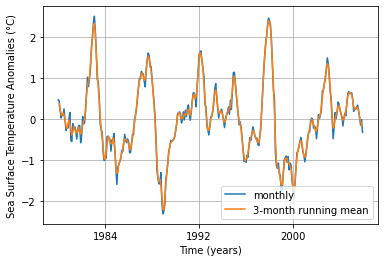

In [10]:
# El Nino index calculus and plot 
ds_nino = ts_dict_atm['amip'].sel(lat=slice(-5, 5), lon=slice(190, 240))

# get nino climatology:

# group the dataset by month
tos_nino34_mon = ds_nino.TS.groupby("time.month")
# find the monthly climatology in the Nino 3.4 region
tos_nino34_clim = tos_nino34_mon.mean(dim="time")
# find the monthly anomaly in the Nino 3.4 region
tos_nino34_anom = tos_nino34_mon - tos_nino34_clim


# take the area-weighted average of anomalies in the Nino 3.4 region
tos_nino34_anom_mean = tos_nino34_anom.weighted(weights).mean( dim=["lat", "lon"] )
print(tos_nino34_anom_mean)

# smooth using a centered 3 month running mean
oni_index = tos_nino34_anom_mean.rolling( time = 3, center=True ).mean()
print (oni_index)

# define the plot size
fig = plt.figure()

# assign axis
ax = plt.axes()

# plot the monhtly data on the assigned axis
tos_nino34_anom_mean.plot(ax=ax)

# plot the smoothed data on the assigned axis
oni_index.plot(ax=ax)

plt.grid(':')

# add legend, xlabel and ylabel
ax.legend(["monthly", "3-month running mean"])
ax.set_ylabel("Sea Surface Temperature Anomalies (°C)")
ax.set_xlabel("Time (years)")
plt.show()

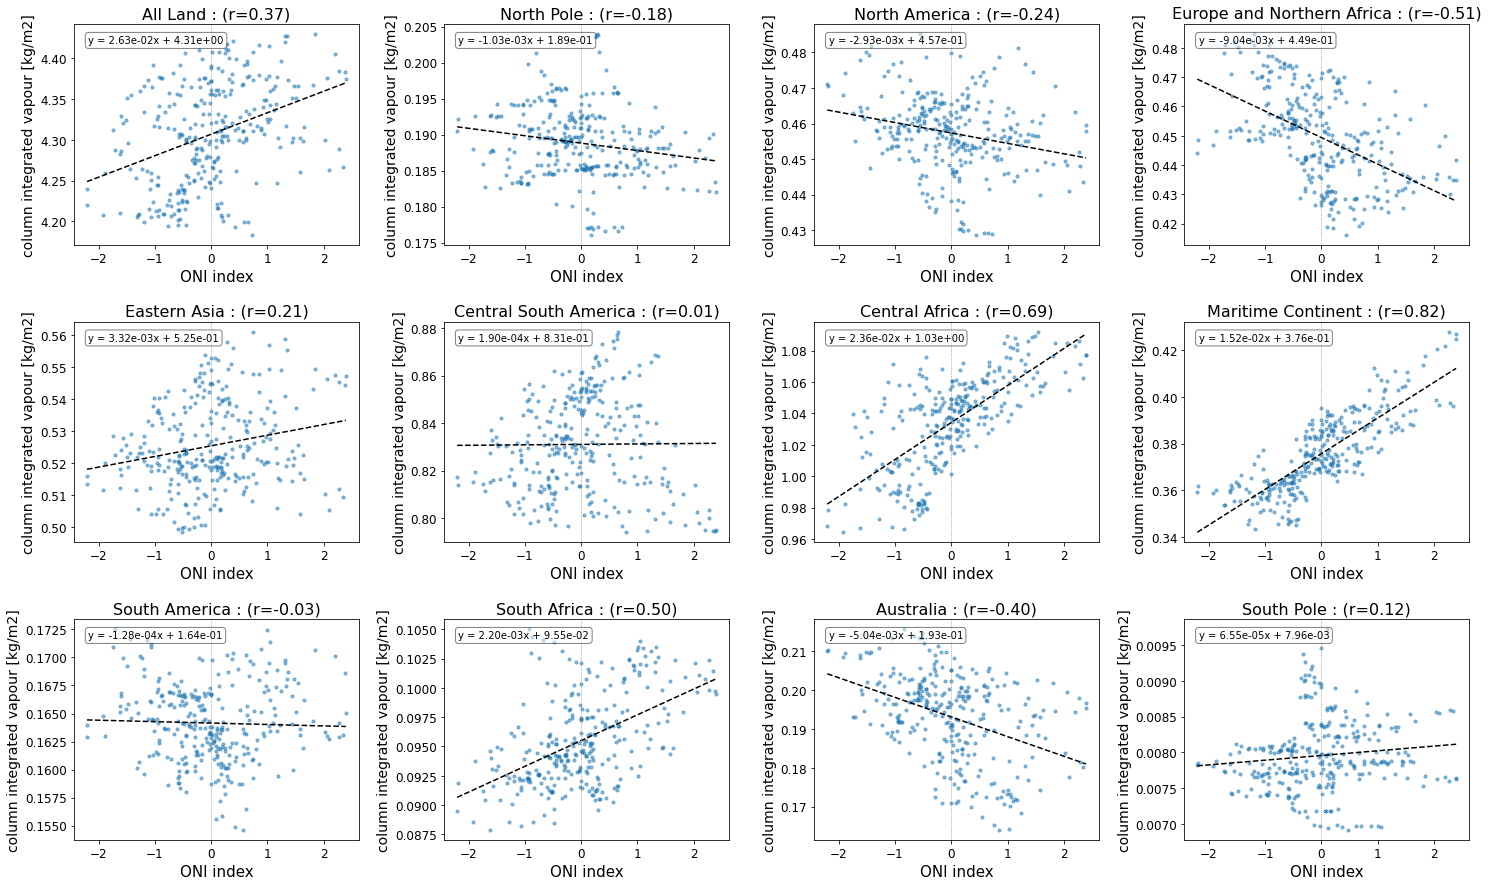

In [20]:
case = 'amip'
tracer_list = ['LNDV', 'NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']

fig, axes = plt.subplots(3, 4, figsize=(25, 15), sharex=True,gridspec_kw={'wspace': 0.3, 'hspace': 0.35})
axes = axes.flatten()

for i, tracer in enumerate(tracer_list):
    ax = axes[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")
    tracer_zm = data_integrated.mean(dim='lon')
    tracer_ts= tracer_zm.weighted(weights).mean(dim='lat')
    tracer_run_mean = tracer_ts.rolling(time=12, center=True).mean()

    #mask needed since there is 3months mean and 12months mean so there are NaN values 
    mask = ~(np.isnan(oni_index.values) | np.isnan(tracer_run_mean.values))
    x, y = oni_index.values [mask], tracer_run_mean.values[mask]
    ax.scatter(x, y, s=10, alpha=0.5, label=tracer)
    
    # Regression line
    a, b = np.polyfit(x, y, 1) # polynomial degree 1
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b, color='black', lw=1.5, ls='--')
    ax.text(0.05, 0.95, f'y = {a:.2e}x + {b:.2e}',transform=ax.transAxes,fontsize=10, 
            color='black', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5))

    # Pearson R
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{tracer_dict_reversed [tracer]} : (r={r:.2f})', fontsize=16)
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('ONI index', fontsize=15)
    ax.set_ylabel('column integrated \n  vapour [kg/m2]', fontsize=14)
    ax.tick_params(labelbottom=True, labelsize=12) 

plt.show()


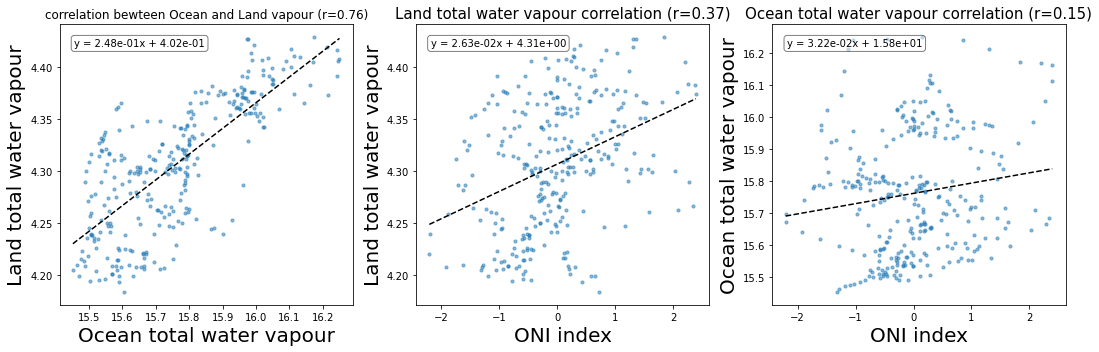

In [23]:
# Correlation between ocean Q and land Q, land Q and El Nino, and ocean Q and el Nino
case = 'amip'
run= 'LNDV'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
weights = np.cos(np.deg2rad(ts_dict_atm[case]['TS'].lat))

data_integrated = xr.open_dataarray("vert_int_output/"+run+".nc")
tracer_zm = data_integrated.weighted(weights).mean(dim=['lat', 'lon'])
tracer_run_mean = tracer_zm.rolling(time=12, center=True).mean()

data_integrated_ocean = xr.open_dataarray("vert_int_output/"+'Q'+".nc") - xr.open_dataarray("vert_int_output/"+'LNDV'+".nc")
tracer_zm_ocean = data_integrated_ocean.mean(dim='lon')
tracer_ts_ocean = tracer_zm_ocean.mean(dim='lat')
tracer_run_mean_ocean = tracer_ts_ocean.rolling(time=12, center=True).mean()

for i in range (3):
    ax = axes[i]
    if i ==0:
        yaxis=tracer_run_mean
        ylabel= 'Land total water vapour' 
        xaxis=tracer_run_mean_ocean
        xlabel='Ocean total water vapour'
    else :
        xaxis= oni_index 
        xlabel= 'ONI index'
        if i==1:
            yaxis=tracer_run_mean
            ylabel= 'Land total water vapour'
        else :
            yaxis=tracer_run_mean_ocean
            ylabel='Ocean total water vapour'
    

    #mask needed since there is 3months mean and 12months mean so there are NaN values 
    mask = ~(np.isnan(xaxis.values) | np.isnan(yaxis.values))
    x, y = xaxis.values [mask], yaxis.values[mask]
    ax.scatter(x, y, s=10, alpha=0.5, label=tracer)
    
    # Regression line
    a, b = np.polyfit(x, y, 1) # polynomial degree 1
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b, color='black', lw=1.5, ls='--')
    ax.text(0.05, 0.95, f'y = {a:.2e}x + {b:.2e}',transform=ax.transAxes,fontsize=10, 
            color='black', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5))
    r = np.corrcoef(x, y)[0, 1]   # Pearson R

    #layout
    if i==0 : ax.set_title(f'correlation bewteen Ocean and Land vapour (r={r:.2f})')
    else :ax.set_title(f'{ylabel} correlation (r={r:.2f})', fontsize=15)
    ax.set_xlabel(xlabel,fontsize=20)
    ax.set_ylabel(ylabel,fontsize=20)
    ax.set_xlim(x.min() - 0.05 * (x.max() - x.min()), x.max() + 0.05 * (x.max() - x.min()))

#plt.suptitle(f'Ocean and Land total water vapor Running Mean correlation with El Nino ', fontsize=22)
plt.tight_layout()

plt.show()

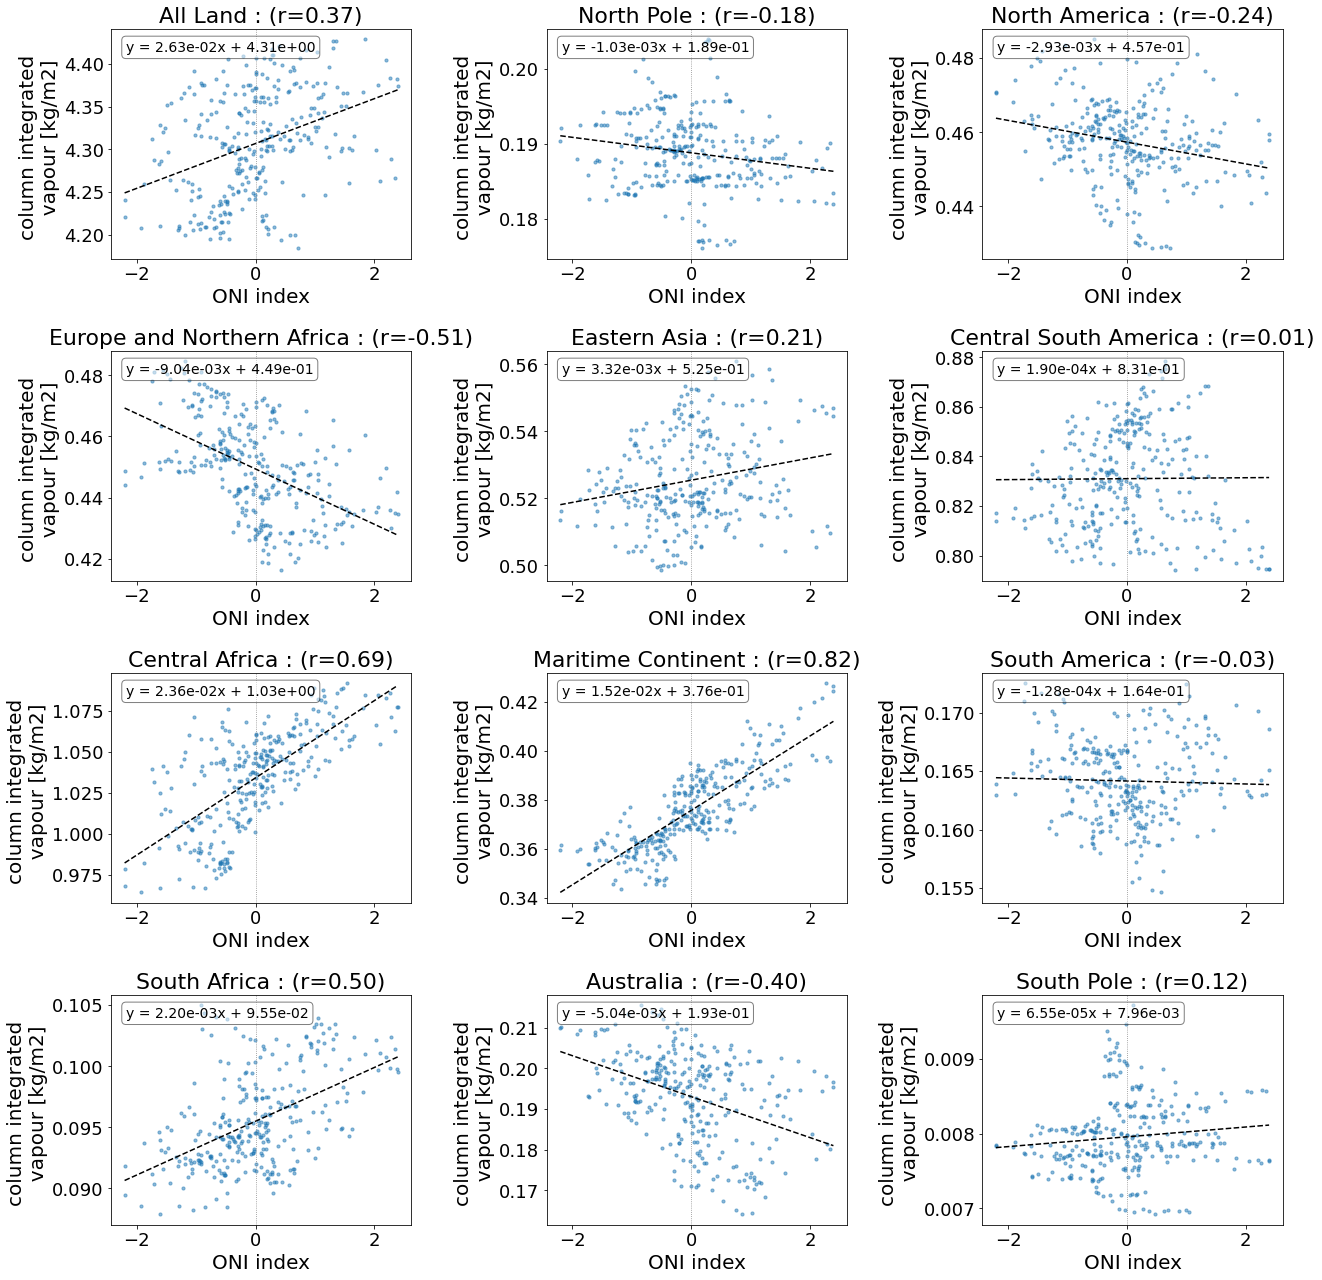

In [21]:
case = 'amip'
tracer_list = ['LNDV', 'NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']

fig, axes = plt.subplots(4, 3, figsize=(21, 22), sharex=True,gridspec_kw={'wspace': 0.45, 'hspace': 0.4})
axes = axes.flatten()

for i, tracer in enumerate(tracer_list):
    ax = axes[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")
    tracer_zm = data_integrated.mean(dim='lon')
    tracer_ts= tracer_zm.weighted(weights).mean(dim='lat')
    tracer_run_mean = tracer_ts.rolling(time=12, center=True).mean()

    #mask needed since there is 3months mean and 12months mean so there are NaN values 
    mask = ~(np.isnan(oni_index.values) | np.isnan(tracer_run_mean.values))
    x, y = oni_index.values [mask], tracer_run_mean.values[mask]
    ax.scatter(x, y, s=10, alpha=0.5, label=tracer)
    
    # Regression line
    a, b = np.polyfit(x, y, 1) # polynomial degree 1
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b, color='black', lw=1.5, ls='--')
    ax.text(0.05, 0.95, f'y = {a:.2e}x + {b:.2e}',transform=ax.transAxes,fontsize=14, 
            color='black', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5))

    # Pearson R
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{tracer_dict_reversed [tracer]} : (r={r:.2f})', fontsize=22)
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('ONI index', fontsize=20)
    ax.set_ylabel('column integrated \n  vapour [kg/m2]', fontsize=20)
    ax.tick_params(labelbottom=True, labelsize=18) 
plt.savefig('nino_all.svg')
plt.show()
